# LTUH Orbit correction

Example orbit correction in LTUH. 

Also see tao/examples/cbeta_ffag in the Bmad distribution for a more complicated case

In [1]:
%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


In [2]:
from pytao import Tao

In [3]:
# Start tao
tao = Tao('-init $LCLS_LATTICE/bmad/examples/ltuh_orbit_correction/tao.init')

## Setup

In [4]:
%%tao
set global derivative_recalc = F 
set global derivative_uses_design = T
set global svd_retreat_on_merit_increase = F


use var correctors.x
set dat orbit.x|meas =0
set dat orbit.x[1:25]|weight =1
set dat orbit.x[28:29]|weight =100
use dat orbit.x
set global optimizer = svd

-------------------------
Tao> set global derivative_recalc = F 
-------------------------
Tao> set global derivative_uses_design = T
-------------------------
Tao> set global svd_retreat_on_merit_increase = F
-------------------------
Tao> 
-------------------------
Tao> 
-------------------------
Tao> use var correctors.x
  correctors.x[1:18]                             Using: 1:18
-------------------------
Tao> set dat orbit.x|meas =0
-------------------------
Tao> set dat orbit.x[1:25]|weight =1
-------------------------
Tao> set dat orbit.x[28:29]|weight =100
-------------------------
Tao> use dat orbit.x
  orbit.x[1:29]                                  Using: 1:29
  orbit.y[1:0]                                   Using:
  orbit.profx[1:0]                               Using:
  orbit.profy[1:0]                               Using:
  orbit.e[1:0]                                   Using:
-------------------------
Tao> set global optimizer = svd
-------------------------
Tao> 


## Add errors 

In [5]:
%%tao
set lattice model=design
! Turn off collimators
set ele rcoll::* x1_limit = 20e-3
set ele rcoll::* x2_limit = 20e-3
change ele quad::* x_offset ran_gauss() * 100e-6

-------------------------
Tao> set lattice model=design
-------------------------
Tao> ! Turn off collimators
-------------------------
Tao> set ele rcoll::* x1_limit = 20e-3
-------------------------
Tao> set ele rcoll::* x2_limit = 20e-3
-------------------------
Tao> change ele quad::* x_offset ran_gauss() * 100e-6
           Old           New    Old-Design    New-Design         Delta
  0.000000E+00  4.076432E-05  0.000000E+00  4.076432E-05  4.076432E-05    QVM1
  0.000000E+00  3.939277E-05  0.000000E+00  3.939277E-05  3.939277E-05    QVM2
  0.000000E+00 -6.652088E-05  0.000000E+00 -6.652088E-05 -6.652088E-05    QVB1
  0.000000E+00 -3.477979E-06  0.000000E+00 -3.477979E-06 -3.477979E-06    QVB2
  0.000000E+00 -2.400350E-05  0.000000E+00 -2.400350E-05 -2.400350E-05    QVB3
  0.000000E+00 -5.023541E-05  0.000000E+00 -5.023541E-05 -5.023541E-05    QVM3
  0.0000000000  0.0001175030  0.0000000000  0.0001175030  0.0001175030    QVM4
  0.0000000000  0.0001017384  0.0000000000  0.0001017384

## Correct

In [6]:
%%tao
set dat orbit.x[1:25]|weight = 1e-3
set dat orbit.x[28:29]|weight =1000000
set global merit_stop_value = 1
set global n_opti_loops = 100
run
run
set global n_opti_loops = 4
set global merit_stop_value = -1
run

-------------------------
Tao> set dat orbit.x[1:25]|weight = 1e-3
-------------------------
Tao> set dat orbit.x[28:29]|weight =1000000
-------------------------
Tao> set global merit_stop_value = 1
-------------------------
Tao> set global n_opti_loops = 100
-------------------------
Tao> run
Optimizing with: svd
Type ``.'' to stop the optimizer before it's finished.
[INFO] tao_dmodel_dvar_calc:
    Remaking dModel_dVar derivative matrix.
    This may take a while...

Hit upper limit of variable: correctors.x[5]
[INFO] tao_veto_vars_with_zero_dmodel:
    Data is independent of Variable: correctors.x[5]
    Will not use this variable in optimization.
Initial Merit:     4.9040E-01
Hit lower limit of variable: correctors.x[7]
Merit after svd:     3.8830E-03
[INFO] tao_run_cmd:
    Merit value below global%merit_stop_value. Stopping Optimization.
-------------------------
Tao> run
Optimizing with: svd
Type ``.'' to stop the optimizer before it's finished.
[INFO] tao_veto_vars_with_zero_d

In [7]:
%%tao
sho var correctors.x

-------------------------
Tao> sho var correctors.x
  Variable                   Slave Parameters           Meas         Model        Design  Useit_opt
  correctors.x[1]            XCVM2[BL_KICK]         0.0000E+00    2.0360E-04   -0.0000E+00       T
  correctors.x[2]            XCVB2[BL_KICK]         0.0000E+00   -2.5796E-04   -0.0000E+00       T
  correctors.x[3]            XCVM3[BL_KICK]         0.0000E+00   -4.5576E-04   -0.0000E+00       T
  correctors.x[4]            XCDL1[BL_KICK]         0.0000E+00    1.2359E-04   -0.0000E+00       T
  correctors.x[5]            XCQT12[BL_KICK]        0.0000E+00   -0.0000E+00   -0.0000E+00       T
  correctors.x[6]            XCDL2[BL_KICK]         0.0000E+00   -2.8618E-04   -0.0000E+00       T
  correctors.x[7]            XCQT22[BL_KICK]        0.0000E+00    0.0000E+00   -0.0000E+00       T
  correctors.x[8]            XCDL3[BL_KICK]         0.0000E+00    3.6787E-04   -0.0000E+00       T
  correctors.x[9]            XCQT32[BL_KICK]        0.00

In [8]:
%%tao
sho lat quad::* -no_slaves -at x_offset

-------------------------
Tao> sho lat quad::* -no_slaves -at x_offset
# Values shown are for the Exit End of each Element:
# Index  name  key                      s       l    x_offset
     94  QT11  Quadrupole        1273.013   0.461  5.7225E-05
    104  QT13  Quadrupole        1275.935   0.461  6.0087E-05
    162  QT21  Quadrupole        1308.824   0.461  1.5006E-04
    172  QT23  Quadrupole        1311.746   0.461 -2.0988E-04
    180  CQ31  Quadrupole        1321.014   0.108  2.2056E-05
    197  CQ32  Quadrupole        1335.014   0.108  8.7759E-06
    204  QT31  Quadrupole        1344.635   0.461 -1.2081E-04
    214  QT33  Quadrupole        1347.557   0.461 -3.9082E-05
    258  QT41  Quadrupole        1380.446   0.461 -3.4161E-05
    268  QT43  Quadrupole        1383.368   0.461  7.2468E-05
    296  QEM3V Quadrupole        1404.062   0.108 -2.0602E-04
Lord Elements:
    436  QVM1  Quadrupole        1210.558   0.461  4.0764E-05
    437  QVM2  Quadrupole        1211.519   0.461  3.93

# Automate

In [9]:
error_cmds = """
set global plot_on = F
set lattice model=design
! Turn off collimators
set ele rcoll::* x1_limit = 20e-3
set ele rcoll::* x2_limit = 20e-3
change ele quad::* x_offset ran_gauss() * 200e-6
"""
def random_errors():
    for cmd in error_cmds.split('\n'):
        tao.cmd(cmd)
random_errors()

In [10]:
correct_cmds="""set dat orbit.x[1:25]|weight = 1e-3
set dat orbit.x[28:29]|weight =1000000
set global merit_stop_value = 1
set global n_opti_loops = 100
run
run
set global n_opti_loops = 4
set global merit_stop_value = -1
run
set global plot_on = T
"""
def correct():
    for cmd in correct_cmds.split('\n'):
        tao.cmd(cmd)    
correct()

In [11]:
# Run in a loop
for i in range(100):
    random_errors()
    correct()

# Response matrix and SVD decomposition

In [12]:
%%time
rmat =tao.derivative()[1]
ndat, nvar = rmat.shape

CPU times: user 6.63 ms, sys: 1.77 ms, total: 8.4 ms
Wall time: 9.87 ms


Text(0.5, 1.0, 'LTUH Corrector-BPM response')

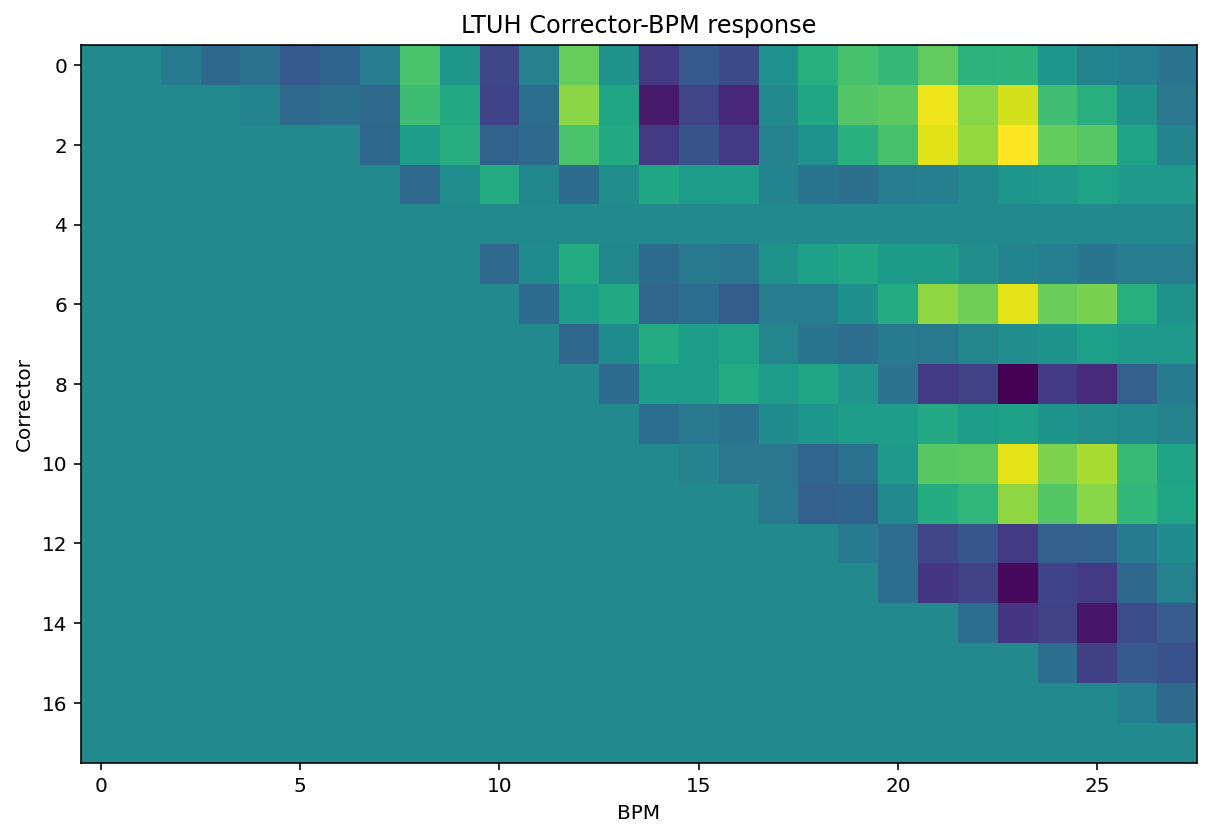

In [13]:
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(rmat.T)
ax.set_xlabel('BPM')
ax.set_ylabel('Corrector')
ax.set_title('LTUH Corrector-BPM response')

In [14]:
u, s, vh = np.linalg.svd(rmat)
s, u.shape, vh.shape

(array([1.37754372e+01, 7.59896573e+00, 2.56680832e+00, 1.67637808e+00,
        1.58183556e+00, 9.72010500e-01, 9.01371594e-01, 8.33657029e-01,
        5.95712592e-01, 5.21995545e-01, 4.92539795e-01, 4.58687809e-01,
        3.72934968e-01, 3.51784041e-01, 2.52222172e-01, 1.92304550e-01,
        6.05369644e-03, 1.08244660e-16]),
 (28, 28),
 (18, 18))

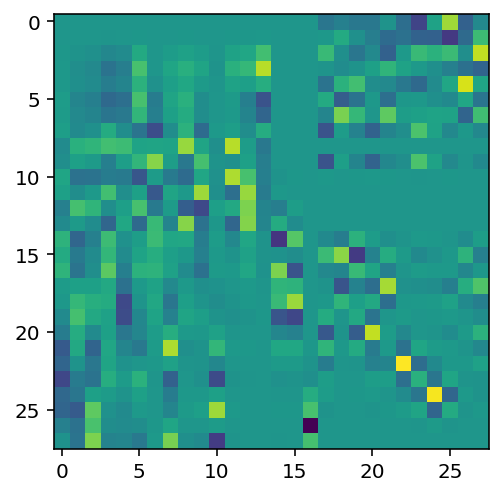

In [15]:
plt.imshow(u)

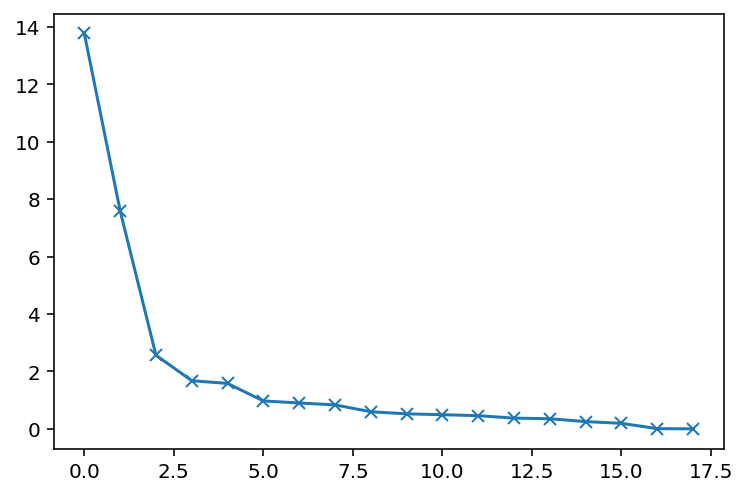

In [16]:
plt.plot(s, marker='x')

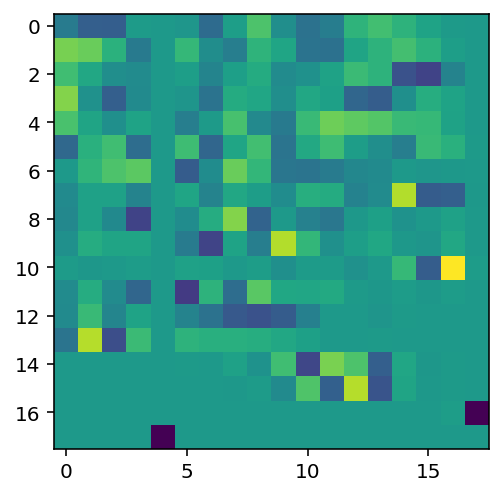

In [17]:
plt.imshow(vh)